<a href="https://qworld.net" target="_blank" align="left"><img src="https://gitlab.com/qworld/qeducation/qbook101/raw/main/qworld/images/header.jpg" align="left"></a>

...adapted from the notes by Abuzer Yakaryilmaz

# Entanglement and Quantum Protocols

In [1]:
import IPython
import matplotlib.pyplot as plt
import numpy as np

from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex
from qiskit_aer import AerSimulator

# 1.0 Two Qubits System

##### A quantum system with two qubits may be represented by any of $ \ket{00}, \ket{01}, \ket{10}, or \, \ket{11}.$

We note here that this is *a very simplistic* representation (each with an amplitude of 1)!

Other forms of combination of each of the states above also exist. Ideally, what matters is the number of qubits used in the notation, and here, we are restricted to two qubits!!!


The state $ \ket{ab} $ means that

- the first qubit is in state $ \ket{a} $ and
- the second qubit is in state $ \ket{b} $,

where $ a,b \in \{0,1\} $.

$ \ket{ab} = \ket{a} \otimes \ket{b} $ (or shortly $\ket{a}\ket{b}$.

<div class="alert alert-block alert-info">
  <b>Sanity check: Which is first and which is second?</b>

The choice of first or second qubit is by convention, and it is important to know which convention
a particular context is using.

Read more on the `little-endian or big-endian` convention.

Beware of qubits counting by indexing (qubit0, qubit1).  

**The qiskit convention is $\ket{qubit1, \,qubit0}$**
    
</div>

## 1.1 Gate Operations: Hadamard and CNOT

### 1.1.1 Hadamard and Superposition

Suppose we think of states in **superposition**!!!

A single qubit state is either a $\ket{0}$ or a $\ket{1}$. A superposition of both could be the state " $\ket{0} + \ket{1}$ " or " $\ket{0} - \ket{1}$ "

<div class="alert alert-block alert-warning">
  <b>Sanity check: Total probability sums up to 1.</b>

In the language of Quantum Mechanics, neither of the above superposition states is **normalized**.

`Normalization requires that the sum of all probabilites sums to 1.`

Can you think of a normalized quantum state?
</div>

Neither of " $\ket{0} \pm \ket{1}$ " is normalized!

The following are examples of superpositions that are normalized:

- $\frac{1}{\sqrt{2}}\ket{0} + \frac{1}{\sqrt{2}}\ket{1}$ or written in shorthand as $\ket{+}$;
- $\frac{1}{\sqrt{2}}\ket{0} - \frac{1}{\sqrt{2}}\ket{1}$ or written in shorthand as $\ket{-}$;
- $\frac{1}{2}\ket{0} + \frac{\sqrt{3}}{2}\ket{1}$;
- $\frac{2}{\sqrt{7}}\ket{0} - \sqrt{\frac{3}{7}}\ket{1}$;  
...and many more!
  
The $\ket{+}$ and $\ket{-}$ states are well known because they are states of equal superposition (for $\ket{0}$ and $\ket{1}).$

The $\frac{1}{\sqrt{2}}$ coefficients are probability amplitudes, and the measurement probability of each outcome is the square of its amplitude.


<div class="alert alert-block alert-success">
  <b>Sanity check: Hadamard and the 50-50 effect</b>


The [Hadamard gate (H)](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.HGate) takes a qubit in a definite state ($|0\rangle$ or $|1\rangle$) and puts it into an equal superposition

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \qquad H|0\rangle = \frac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr) = |+\rangle$$

Measuring the $|+\rangle$ state gives 0 or 1 with equal probability (50% each). 


What is $H|1\rangle$?

</div>


### 1.1.2 Hadamard and Superposition (Circuit Representation using Qiskit)

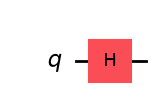

In [2]:
#Adding Hadamard to a single qubit
qc = QuantumCircuit(1)

# TODO: Add a Hadamard gate on qubit 0: H|0>
qc.h(0)

qc.draw("mpl")


##### Showing the Statevector (using Qiskit)

In [3]:
sv = Statevector(qc)
display(sv.draw("latex"))

<IPython.core.display.Latex object>

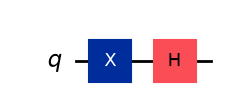

In [4]:
#Repeat for H|1>
qc1 = QuantumCircuit(1)

# TODO: Add a X gate on qubit 0 to create a |1>
qc1.x(0)
# TODO: Add a Hadamard gate on qubit 0 : H|1>
qc1.h(0)

qc1.draw("mpl")


In [5]:
sv1 = Statevector(qc1)
display(sv1.draw("latex"))

<IPython.core.display.Latex object>

## 1.2 Back to Two Qubits: on Superposition and Entanglement

A (single-qubit) quantum system can be in different superpositions (Hadamard gate only gives equal superposition) of possible single qubit states.

Following the postulates of Quantum Mechanics, a two qubits quantum system can also be in different superpositions of possible two qubit states. In general, superposition is possible for any n-qubit states.

Earlier we stated that two qubits may be represented by any of $ \ket{00}, \ket{01}, \ket{10}, or \, \ket{11}$.

Hence the following are examples of normalized two-qubits superposition:

- $\frac{1}{2}\ket{00} \pm \frac{1}{2}\ket{01} \pm \frac{1}{2}\ket{10} \pm \frac{1}{2}\ket{11}$

<div class="alert alert-block alert-success">
  <b>Sanity check: The Hadamard effect on 2 qubits</b>

    Can you understand that the above can be expanded into 24 distinct equal superpositions of all 4 possible two qubits representations?

</div>

- $\frac{2}{5}\ket{00} - \frac{\sqrt{7}}{5}\ket{01} - \frac{3}{5}\ket{10} + \frac{\sqrt{5}}{5}\ket{11}$

## 1.3 From Superposition to Entanglement

The state
$\frac{1}{\sqrt{2}}\ket{00} + \frac{1}{\sqrt{2}}\ket{01}$
is an interesting superposition of the two qubits states $\ket{00}$ and $\ket{01}$.

Also, it can easily be decomposed into a product of two distinct "one qubit" states: a $\ket{0}$ state and a $\ket{+}$.

$$\frac{1}{\sqrt{2}}\ket{00} + \frac{1}{\sqrt{2}}\ket{01} = \ket{0} \otimes \frac{\ket{0} + \ket{1}}{\sqrt{2}} = \ket{0} \otimes \ket{+}$$

All true two qubits superpositions are decomposable into products of two distinct "one qubit" states.

If it is not possible to decompose a two qubit state into product of two "one qubit" states, then we have an `entangled state`.

In general, any $n>=2$ qubit states can form entangled states.

The (four) **bell states** are common examples of maximally entangled two qubits states.

<div class="alert alert-block alert-info">
  <b>Sanity check: Entanglement is here!!!</b>

Two of the four **bell states** are the entangled states: $\frac{\ket{00} + \ket{11}}{\sqrt{2}}$ and $\frac{\ket{01} - \ket{10}}{\sqrt{2}}$

</div>

### 1.3.1 The CX (CNOT) Gate and Entanglement

The CX gate is a **two-qubit** gate. It flips the **target** qubit if and only if the **control** qubit is $\ket{1}$.

When the control is in **superposition**, something remarkable happens: the two qubits become **entangled**. Their measurement outcomes become perfectly correlated in a way that has no classical explanation.

This is purely quantum mechanical!

Let us see the CNOT gate in action using qiskit.

<div class="alert alert-block alert-success">
<b> Sanity check: CNOT in action</b>

Using the circuit below, we would try the following

1. (already given) Create a two qubit circuit, and observe the Statevector
2. Return to circuit, then apply <b>CNOT</b> to named qubits, observe the statevector again.
3. Return to circuit, put control qubit in state |1>, observe the statevector again.
4. Return to circuit, put control qubit in state |1>, then apply <b>CNOT</b>, observe the statevector again.

    `Do you observe that the target qubit is also flipped to |1>?`

5. Return to circuit, try different combinations on control and target qubits, apply <b>CNOT</b>, observe the statevector again.

</div>

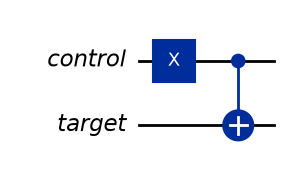

In [10]:
# visualizing CNOT in action

# Create named quantum registers
qctrl = QuantumRegister(1, 'control')
qtarg = QuantumRegister(1, 'target')

# Build the circuit using the named registers
qcnot = QuantumCircuit(qctrl, qtarg)

#TO-DO 2: Apply CNOT gate
#qcnot.cx(qctrl[0],qtarg[0])

#TO-DO 3: put control qubit in state |1>
#qcnot.x(qctrl[0])

#TO-DO 4: put control qubit in state |1>
qcnot.x(qctrl[0])
qcnot.cx(qctrl[0],qtarg[0])


qcnot.draw('mpl')

In [11]:
# display the Statevector
sv3 = Statevector(qcnot)
display(sv3.draw('latex'))

<IPython.core.display.Latex object>

### 1.3.2 Now let's get entangled!

When the control is in **superposition**, and CNOT is applied as before, something remarkable happens: the two qubits become **entangled**.

We can now combine Hadamard and CNOT in a remarkable way to see the two qubits entangled!

With equal superpositions (using Hadamard) and CNOT, we can create the four bell states.

Here is how to create one of them!

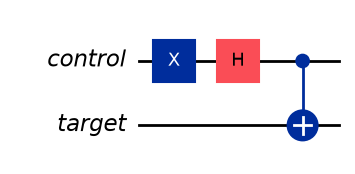

In [13]:
# Creating Bell States

# Create named quantum registers
qctrl = QuantumRegister(1, 'control')
qtarg = QuantumRegister(1, 'target')

# Build the circuit using the named registers
qbell = QuantumCircuit(qctrl, qtarg)

#TO-DO 2: create a bell state
qbell.x(qctrl[0]) 
#qbell.x(qtarg[0])

qbell.h(qctrl[0])
qbell.cx(qctrl[0],qtarg[0])


qbell.draw('mpl')

In [14]:
# display the Statevector
sv4 = Statevector(qbell)
display(sv4.draw('latex'))

<IPython.core.display.Latex object>

<div class="alert alert-block alert-success">
<b>Sanity check: All Four Bell States</b>

Can you try building all 4 Bell states?  
1. $$\ket{\psi^+} = \frac{\ket{00} + \ket{11}}{\sqrt{2}}$$   
2. $$\ket{\psi^-} = \frac{\ket{00} - \ket{11}}{\sqrt{2}}$$ 
3. $$\ket{\phi^+} = \frac{\ket{01} + \ket{10}}{\sqrt{2}}$$
4. $$\ket{\phi^-} = \frac{\ket{01} - \ket{10}}{\sqrt{2}}$$

    `What combinations of gates do you need?`

</div>

# 2.0 Entanglement in action: Quantum Protocols

## 2.1 Entanglement and Superdense Coding

Suppose Asja and Balvis share two entangled qubits of the form
$$\ket{\psi^+} = \frac{\ket{00} + \ket{11}}{\sqrt{2}}$$

We are guaranteed that these qubits are entangled because of **the correlation** between them described as follows:
- If both qubits are measured, we can observe either state $\ket{00}$ or $\ket{11}$ with equal probabilities;
- If Asja secretly measures her qubit, and Balvis also secretly measures his qubit, both of them will observe the same result (of either $\ket{0}$ or $\ket{1}$.   

This is the nature of how their entangled qubits are correlated. Once Asja sees the result $\ket{0}$, it is guaranteed that Balvis will also see the result $\ket{0}$. This correlation is in the entanglement!

**Entangled qubits can be useful.**

## 2.1.1 Quantum Communication: Superdense coding

Superdense coding is a quantum communication protocol that lets you send two classical bits of information by transmitting only a single physical qubit, provided the sender and receiver share an entangled pair of qubits beforehand.


<img src="https://gitlab.com/qworld/qeducation/qbook101/raw/main/qbook101/images/ch2/superdense-coding.jpg" align="left" width="800px">

Using the figure above where Asja and Balvis share an entangled qubit, we conceive of the idea that Balvis goeas away with one of the entangled pair and Asja intends to send two classical bits of information to Balvis by only sending her qubit to him at a later time.

**We describe the protocol as follows:**

- Asja has two bits of classical information: $ a,b \in \{0,1\} $.

- There are four possible values for the pair $ (a,b) $:  $ (0,0), (0,1), (1,0),\mbox{ or } (1,1) $.

- If $a$ is 1, then Asja applies z-gate, i.e., $Z$, to her qubit.

If $b$ is 1, then Asja applies x-gate (NOT operator) to her qubit.

Then, **Asja sends her qubit to Balvis.**



<h3> After the communication </h3>

Balvis has both qubits.

Balvis applies cx-gate (CNOT operator), where Asja's qubit is the controller.

Then, Balvis applies h-gate (Hadamard operator) to Asja's qubit.

Balvis measures both qubits.

The measurement result will be exactly $ (a,b) $.

In [15]:
# Build Superdense protocol circuit
def sdense(msg):
    # Create a circuit with 2 qubits and 2 classical bits
    qc = QuantumCircuit(2, 2)
    
    # Step 1: Prepare a Bell pair (entangled state)
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()
    
    # Step 2: Asja encodes her 2-bit message (e.g., "11")
    if msg == "01":
        qc.z(0)
    elif msg == "10":
        qc.x(0)
    elif msg == "11":
        qc.z(0)
        qc.x(0)
    qc.barrier()
    
    # Step 3: Balvis decodes the message using CNOT and Hadamard
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    
    # Step 4: Measure both qubits
    qc.measure([0, 1], [0, 1])

    return qc

<div class="alert alert-block alert-success">
<b>Sanity check: Superdense coding protocol breakdown</b>

`Can you visualize the 3 key steps in Superdense coding?`

* **Entanglement Creation**: Apply a Hadamard gate (`H`) to qubit 0, followed by a CNOT gate (`cx`) controlled by qubit 0 targeting qubit 1.

*  **Message Encoding**: Asja applies Pauli gates based on her message (`00` = do nothing, `01` = Z, `10` = X, `11` = Z then X) to her qubit before sending it to Balvis.

*  **Decoding & Measurement**: Balvis applies a CNOT gate and a Hadamard gate to reverse the entanglement, then measures both qubits to recover Asja's 2-bit message.

</div>

<div class="alert alert-block alert-info">
<b>Sanity check: Reminder on single qubit Z-gate</b>

`How does the Z gate operate?`

- $Z\ket{0}$ = $\ket{0}$
- $Z\ket{1}$ = $- \ket{1}$

</div>


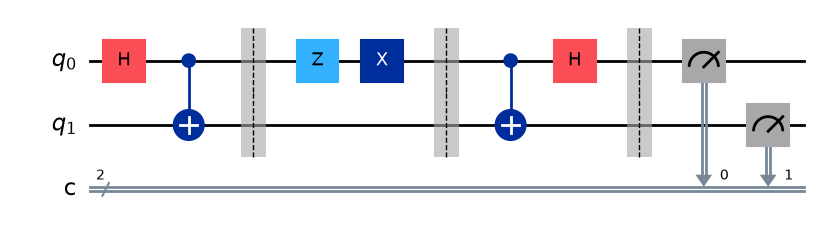

In [18]:
# Decide what message to send
msg = "11"

# apply protocol for msg
qc_dense = sdense(msg)

#display circuit
qc_dense.draw('mpl')

In [19]:
# Let's run the simulation to check measurement results
simulator = AerSimulator()
result = simulator.run(qc_dense, shots=1024).result()
counts = result.get_counts()

print(f"Measurement Counts: {counts}")

Measurement Counts: {'11': 1024}


### Can we trace the Superdense coding protocol 'Statevectors'?

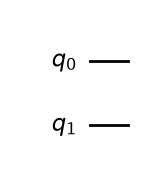

In [23]:
#choose what message to encode

msg = "10"

# Create a circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2)
qc.draw('mpl')

In [24]:
sd0 = Statevector(qc)
display(sd0.draw('latex'))

<IPython.core.display.Latex object>

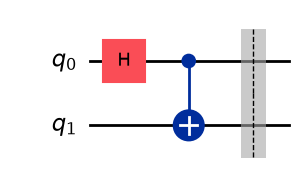

In [25]:
# Step 1: Prepare a Bell pair (entangled state)
qc.h(0)
qc.cx(0, 1)
qc.barrier()

qc.draw('mpl')

In [26]:
sd1 = Statevector(qc)
display(sd1.draw('latex'))

<IPython.core.display.Latex object>

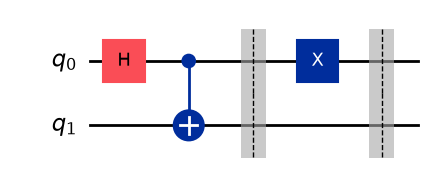

In [27]:
# Step 2: Asja encodes her 2-bit message
if msg == "01":
    qc.z(0)
elif msg == "10":
    qc.x(0)
elif msg == "11":
    qc.z(0)
    qc.x(0)
qc.barrier()

qc.draw('mpl')

In [28]:
sd2 = Statevector(qc)
display(sd2.draw('latex'))

<IPython.core.display.Latex object>

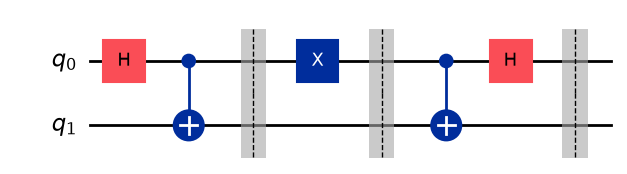

In [29]:
# Step 3: Balvis decodes the message using CNOT and Hadamard
qc.cx(0, 1)
qc.h(0)
qc.barrier()

qc.draw('mpl')

In [30]:
sd3 = Statevector(qc)
display(sd3.draw('latex'))

<IPython.core.display.Latex object>

<div class="alert alert-block alert-info">
<b>Sanity check: Encoding in action </b>

You may want to return to the start of the statevector trace and build the intuition for other encoded messages.

- Try `msg = "01", "11", and "00"`

</div>


## 2.2 Entanglement and Quantum Teleportation

Quantum teleportation is a protocol that transfers exact quantum state information from one quantum particle to a distant particle using entanglement and classical communication, **without moving the physical matter itself**.

Asja wants to send a qubit to Balvis by using only classical communication.

Let $ \ket{v} = \pmatrix{a\\b} \in \mathbb{R}^2 $ be the quantum state.

_Discussion:_ If Asja has many copies of this qubit, then she can collect the statistics based on these qubits and obtain an approximation of $ a $ and $ b $, say $ \tilde{a} $ and $\tilde{b}$, respectively. After this, Asja can send $ \tilde{a} $ and $\tilde{b}$ by using many classical bits, the number of which depends on the precision of the amplitudes.

On the other hand, If Asja and Balvis share the entangled qubits in state $\frac{1}{\sqrt{2}}\ket{00} + \frac{1}{\sqrt{2}}\ket{11}$ in advance, then it is possible for Balvis to create $ \ket{v} $ in his qubit after receiving two bits of information from Asja.

<h3> Protocol </h3>

The protocol uses three qubits as specified below:

<img src='https://gitlab.com/qworld/qeducation/qbook101/raw/main/qbook101/images/ch2/quantum_teleportation_qubits.png' width="25%" align="left">

Asja has two qubits and Balvis has one qubit.

Asja's quantum message (key) is $ \ket{v} = \pmatrix{a\\b} = a\ket{0} + b\ket{1} $.

The entanglement between Asja's second qubit and Balvis' qubit is  $ \frac{1}{\sqrt{2}}\ket{00} + \frac{1}{\sqrt{2}}\ket{11} $.

So, the quantum state of the three qubits is

$$ \big(a\ket{0} + b\ket{1}\big) \otimes \big(\frac{1}{\sqrt{2}}\ket{00} + \frac{1}{\sqrt{2}}\ket{11}\big)
    = \frac{1}{\sqrt{2}}\big( a\ket{000} + a \ket{011} + b\ket{100} + b \ket{111} \big).  $$

Let's visualize the protocol so far and determine the trace the statevectors using qiskit.

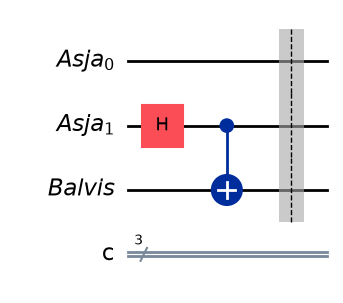

In [31]:
# visualizing Quantum Teleportation

# Create named quantum registers
asj = QuantumRegister(2, 'Asja')
bal = QuantumRegister(1, 'Balvis')
cr = ClassicalRegister(3, "c")

# Build the circuit using the named registers
qc_tel = QuantumCircuit(asj, bal, cr)

#TO-DO 1: Create Entanglement with one of Asja qubits and Balvis qubit
qc_tel.h(asj[1])
qc_tel.cx(asj[1],bal[0])

qc_tel.barrier()
qc_tel.draw('mpl')

In [32]:
sT = Statevector(qc_tel)
display(sT.draw('latex'))

<IPython.core.display.Latex object>

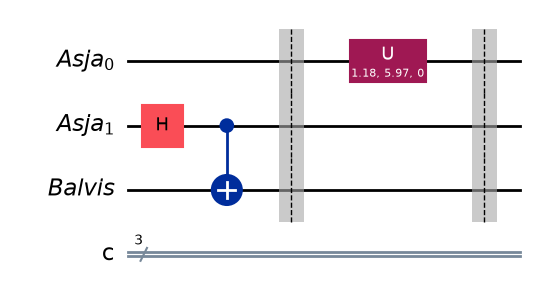

In [33]:
#TO-DO 2: Encode one of Asja's qubits into state |v>
# We can use random variables to create the secret |v> state.
# Don't worry about the "u" gate and the details.

np.random.seed(42)  # fixing seed for repeatability
theta = np.random.uniform(0.0, 1.0) * np.pi  # from 0 to pi
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi

qc_tel.u(theta, varphi, 0.0, asj[0])
qc_tel.barrier()

qc_tel.draw('mpl')

In [34]:
sT = Statevector(qc_tel)
display(sT.draw('latex'))

<IPython.core.display.Latex object>

<div class="alert alert-block alert-info">
  <b>Sanity check: Qubit numbering?</b>

The choice of first, second and third qubit is by convention, and it is important to know which convention
a particular context is using.

**The qiskit convention is $\ket{qubit2, \, qubit1, \,qubit0}$**

`Can you compare the state vector above to the earlier one we had in the calculation?`
- What is the value of `a` and `b` in our sample teleportation cicuit?

</div>

So, the quantum state of the three qubits is

$$ \big(a\ket{0} + b\ket{1}\big) \otimes \big(\frac{1}{\sqrt{2}}\ket{00} + \frac{1}{\sqrt{2}}\ket{11}\big)
    = \frac{1}{\sqrt{2}}\big( a\ket{000} + a \ket{011} + b\ket{100} + b \ket{111} \big).  $$

<h4> CNOT operator by Asja </h4>

Asja applies CNOT gate to her qubits where $q[2]$ is the control qubit and $q[1]$ is the target qubit.

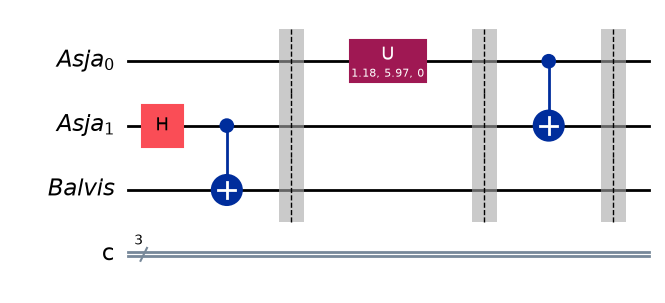

In [35]:
#TO-DO 3: Asja applies CNOT
qc_tel.cx(asj[0],asj[1])
qc_tel.barrier()

qc_tel.draw('mpl')


In [36]:
sT = Statevector(qc_tel)
display(sT.draw('latex'))

<IPython.core.display.Latex object>

<h3>Hadamard operator by Asja</h3>

Asja applies Hadamard gate to $q[2]$.

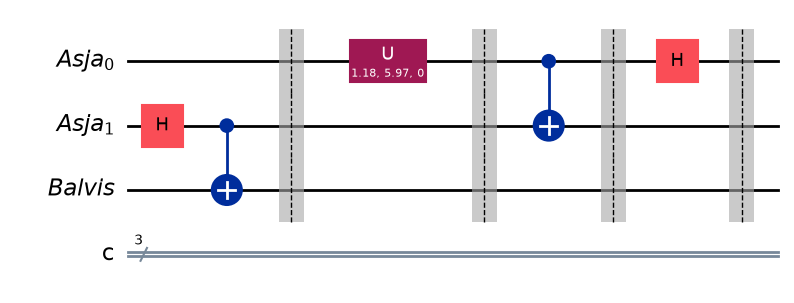

In [37]:
#TO-DO 4: Asja applies Hadamard
qc_tel.h(asj[0])
qc_tel.barrier()

qc_tel.draw('mpl')


In [38]:
sT = Statevector(qc_tel)
display(sT.draw('latex'))

<IPython.core.display.Latex object>

<div class="alert alert-block alert-info">
  <b>Sanity check: Beware of Qiskit Qubits numbering?</b>

Can you verify that the resulting quantum state can be written as follows:

$$  
    \frac{1}{2} \ket{00} \big( a\ket{0}+b\ket{1} \big) +
    \frac{1}{2} \ket{01} \big( a\ket{1}+b\ket{0} \big) +
    \frac{1}{2} \ket{10} \big( a\ket{0}-b\ket{1} \big) +
    \frac{1}{2} \ket{11} \big( a\ket{1}-b\ket{0} \big) .
$$

</div>

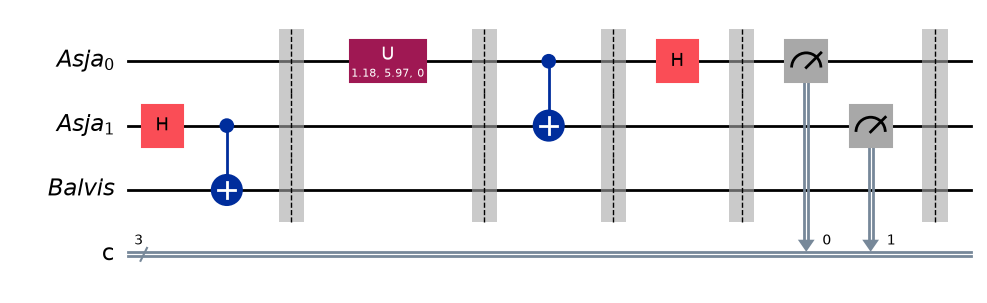

In [39]:
#TO-DO 5: Asja measures her qubits
qc_tel.measure([asj[0],asj[1]],[cr[0],cr[1]])
qc_tel.barrier()

qc_tel.draw('mpl')


<h3> Measurement by Asja </h3>

Asja measures her qubits. With probability $ \frac{1}{4} $, she can observe one of the basis states.

Depeding on the measurement outcomes, Balvis' qubit is in the following states:

1. "00": $ \ket{v_{00}} = a\ket{0} + b \ket{1} $
2. "01": $ \ket{v_{01}} =  a\ket{1} + b \ket{0} $
3. "10": $ \ket{v_{10}} =  a\ket{0} - b \ket{1} $
4. "11": $ \ket{v_{11}} =  a\ket{1} - b \ket{0} $


As can be observed, the amplitudes $ a $ and $ b $ are "transferred" to Balvis' qubit in each case.

If Asja sends the measurement outcomes, then Balvis can construct $ \ket{v} $ exactly.

Balvis can will need to apply a `X` gate (for `01`), a `Z` gate (for `10`), or a sequence of `XZ` gate (for `11`).

Can you see why?

### 2.2.1 The Complete Teleportation Circuit

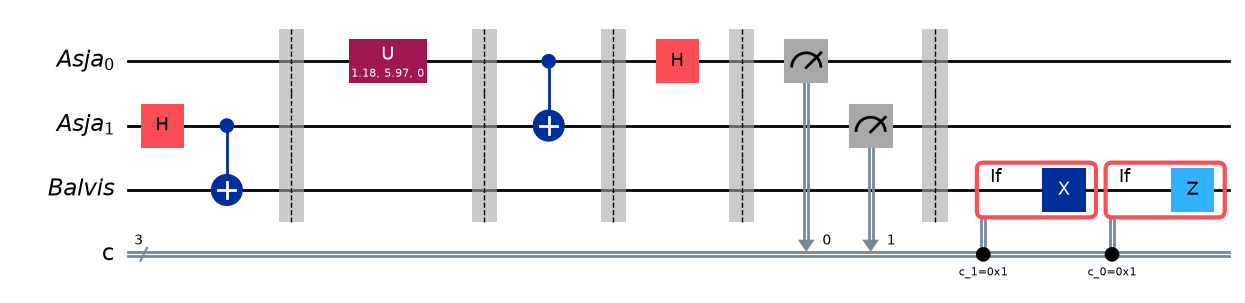

In [40]:
# visualizing Quantum Teleportation

# Create named quantum registers
asj = QuantumRegister(2, 'Asja')
bal = QuantumRegister(1, 'Balvis')
cr = ClassicalRegister(3, "c")

# Build the circuit using the named registers
qc_tel = QuantumCircuit(asj, bal, cr)

#TO-DO 1: Create Entanglement with one of Asja qubits and Balvis qubit
qc_tel.h(asj[1])
qc_tel.cx(asj[1],bal[0])

qc_tel.barrier()

#TO-DO 2: Encode one of Asja's qubits into state |v>
# We can use random variables to create the secret |v> state.
# Don't worry about the "u" gate and the details.

np.random.seed(42)  # fixing seed for repeatability
theta = np.random.uniform(0.0, 1.0) * np.pi  # from 0 to pi
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi

qc_tel.u(theta, varphi, 0.0, asj[0])
qc_tel.barrier()

#TO-DO 3: Asja applies CNOT
qc_tel.cx(asj[0],asj[1])
qc_tel.barrier()

#TO-DO 4: Asja applies Hadamard
qc_tel.h(asj[0])
qc_tel.barrier()

#TO-DO 5: Asja measures her qubits
qc_tel.measure([asj[0],asj[1]],[cr[0],cr[1]])
qc_tel.barrier()

# Balvis final conditional steps

with qc_tel.if_test((cr[1], 1)):
    qc_tel.x(bal[0])
with qc_tel.if_test((cr[0], 1)):
    qc_tel.z(bal[0])

qc_tel.draw('mpl')

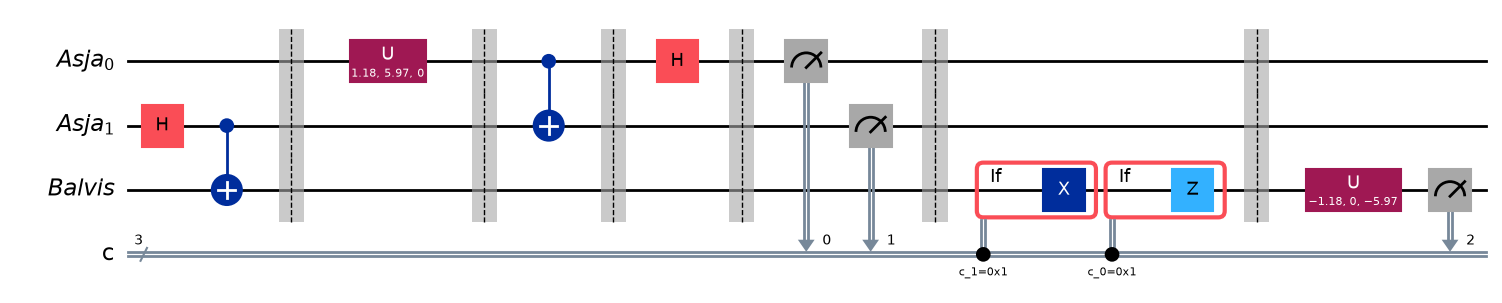

In [41]:
# Optional initial state recovery

# Add the inverse of U and measure Balvis qubit.
qc_tel.barrier()

qc_tel.u(theta, varphi, 0.0, bal[0]).inverse()  # inverse of u(theta,varphi,0.0)
qc_tel.measure(bal[0], cr[2])  # add measurement gate

qc_tel.draw(output="mpl")